In [80]:
R.version.string

[1] "R version 4.4.2 (2024-10-31)"

In [2]:
# ----------- Load Required Libraries -----------
library(phyloseq)
library(dplyr)
library(tidyr)
library(ggplot2)
library(forcats)
library(scales)
library(viridis)
library(ggpubr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal




In [3]:
## Relative abundance 

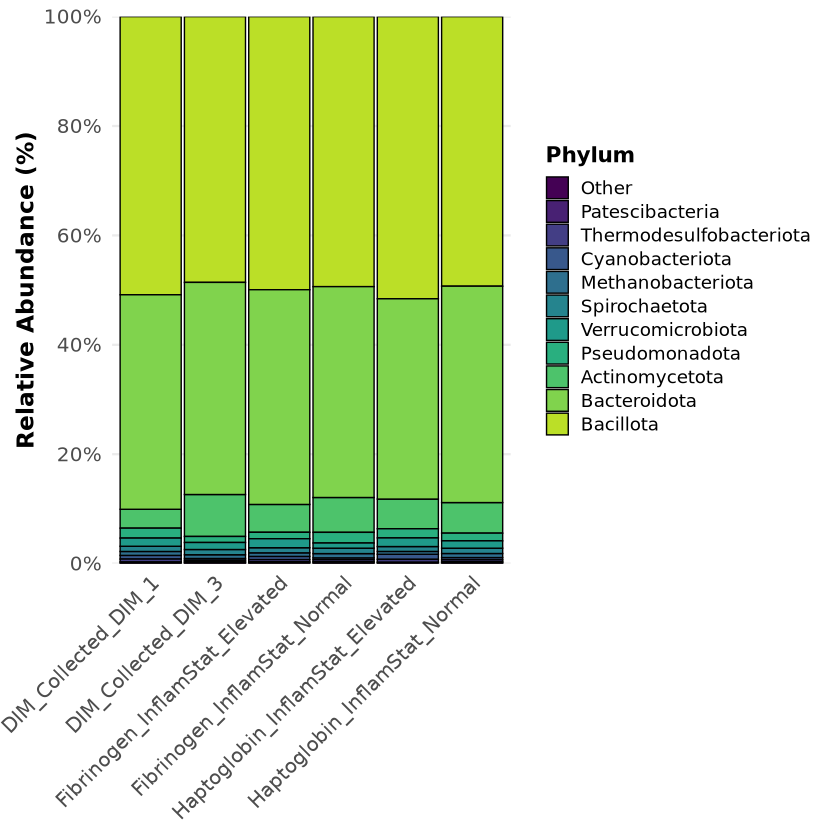

In [59]:
# ----------- Load Required Libraries -----------
library(phyloseq)
library(dplyr)
library(ggplot2)
library(forcats)
library(viridis)

# ----------- Load Your Phyloseq Object -----------
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/GP_ps.st.decontam.rds")

# ----------- Clean Taxonomy -----------
tax_clean <- tax_table(ps) %>% as.data.frame()
for (i in seq_along(tax_clean)) {
  tax_clean[[i]] <- as.character(tax_clean[[i]])
  tax_clean[[i]][is.na(tax_clean[[i]]) | tax_clean[[i]] == ""] <- paste("Unclassified", colnames(tax_clean)[i])
}
tax_table(ps) <- tax_table(as.matrix(tax_clean))

# ----------- Relative Abundance Preparation Function -----------
prepare_phylum_plot_data <- function(group_var, top_n = 10) {
  meta <- sample_data(ps) %>% as.data.frame()
  meta <- meta[!is.na(meta[[group_var]]), ]

  if (group_var %in% c("DIM", "DIM_Collected")) {
    meta[[group_var]] <- paste0("DIM_", as.character(meta[[group_var]]))
  }

  ps_sub <- prune_samples(rownames(meta), ps)
  sample_data(ps_sub)[[group_var]] <- meta[[group_var]]

  ps_tax <- tax_glom(ps_sub, taxrank = "Phylum")
  ps_rel <- transform_sample_counts(ps_tax, function(x) x / sum(x))
  df <- psmelt(ps_rel)

  df$Phylum <- as.character(df$Phylum)
  df$Phylum[is.na(df$Phylum) | df$Phylum == ""] <- "Unclassified_Phylum"

top_phyla <- df %>%
  group_by(Phylum) %>%
  summarise(MeanRA = mean(Abundance), .groups = "drop") %>%
  arrange(desc(MeanRA)) %>%
  slice_head(n = top_n) %>%
  pull(Phylum)

df$Phylum <- ifelse(df$Phylum %in% top_phyla, df$Phylum, "Other")



  df <- df %>%
    group_by(Sample) %>%
    mutate(Abundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df$CompositeGroup <- paste0(group_var, "_", df[[group_var]])

  df_summary <- df %>%
    group_by(Sample, CompositeGroup, Phylum) %>%
    summarise(Abundance = sum(Abundance), .groups = "drop") %>%
    group_by(Sample, CompositeGroup) %>%
    mutate(RelAbundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df_summary %>%
    group_by(CompositeGroup, Phylum) %>%
    summarise(RelAbundance = mean(RelAbundance), .groups = "drop") %>%
    group_by(CompositeGroup) %>%
    mutate(RelAbundance = ifelse(row_number() == n(),
                                 pmin(RelAbundance, 1 - sum(RelAbundance[-n()])),
                                 RelAbundance)) %>%
    ungroup()
}

# ----------- Plotting Function -----------
plot_phylum_abundance <- function(df, output_prefix = "phylum_abundance", output_dir = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs") {
  df$Phylum <- fct_reorder(df$Phylum, df$RelAbundance, .fun = sum)

  p <- ggplot(df, aes(x = CompositeGroup, y = RelAbundance * 100, fill = Phylum)) +
    geom_col(
      width = 0.95,
      position = position_stack(reverse = TRUE),
      na.rm = TRUE,
      color = "black",       # Add black border to each stack
      linewidth = 0.4        # Thin edge for clarity
    ) +
    scale_y_continuous(
      labels = function(x) paste0(x, "%"),
      limits = c(0, 100),
      breaks = seq(0, 100, by = 20),
      expand = c(0, 0)
    ) +
    scale_fill_viridis_d(option = "D", begin = 0, end = 0.9) +
    labs(
      x = NULL,
      y = "Relative Abundance (%)",
      fill = "Phylum"
    ) +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
      axis.text.y = element_text(size = 12),
      axis.title.y = element_text(size = 14, face = "bold"),
      legend.title = element_text(size = 13, face = "bold"),
      legend.text = element_text(size = 11),
      legend.key.height = unit(0.5, "cm"),
      legend.key.width = unit(0.5, "cm"),
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank(),
      plot.margin = margin(10, 10, 10, 10)
    )

  ggsave(file.path(output_dir, paste0(output_prefix, ".tiff")), plot = p, width = 10, height = 6, dpi = 300)
  ggsave(file.path(output_dir, paste0(output_prefix, ".png")), plot = p, width = 10, height = 6, dpi = 300)

  return(p)
}

# ----------- Run and Visualize -----------
df_phylum <- bind_rows(
  prepare_phylum_plot_data("Haptoglobin_InflamStat", top_n = 10),
  prepare_phylum_plot_data("Fibrinogen_InflamStat", top_n = 10),
  prepare_phylum_plot_data("DIM_Collected", top_n = 10)
)

p <- plot_phylum_abundance(df_phylum)
print(p)


In [56]:
# Group phyla with mean relative abundance < 1% into "Other"
low_abundance_phyla <- df %>%
  group_by(Phylum) %>%
  summarise(MeanRA = mean(Abundance), .groups = "drop") %>%
  filter(MeanRA < 0.01) %>%
  pull(Phylum)

df$Phylum <- ifelse(df$Phylum %in% low_abundance_phyla, "Other", df$Phylum)

In [62]:
# ----------- Load Required Libraries -----------
library(phyloseq)

# ----------- Step 1: Extract OTU count matrix -----------
otu_counts <- as(otu_table(ps), "matrix")

# If taxa are rows, transpose
if (taxa_are_rows(ps)) {
  otu_counts <- t(otu_counts)
}

# ----------- Step 2: Clean and Extract Copy Number -----------
meta_df <- as(sample_data(ps), "data.frame")

# Clean qpcr_16s_copies_ul
meta_df$qpcr_16s_copies_ul <- gsub(",", "", meta_df$qpcr_16s_copies_ul)
meta_df$qpcr_16s_copies_ul[meta_df$qpcr_16s_copies_ul %in% c("", "NA", "na", "N/A")] <- NA
meta_df$qpcr_16s_copies_ul <- as.numeric(meta_df$qpcr_16s_copies_ul)

# Update cleaned metadata back to phyloseq
sample_data(ps)$qpcr_16s_copies_ul <- meta_df$qpcr_16s_copies_ul

# ----------- Step 3: Get numeric vector of copy number in correct order -----------
copy_number <- meta_df[rownames(otu_counts), "qpcr_16s_copies_ul"]

# Final check
stopifnot(is.numeric(copy_number))
if (any(is.na(copy_number))) {
  cat("Samples with NA qpcr_16s_copies_ul:\n")
  print(rownames(otu_counts)[is.na(copy_number)])
  stop("Some samples have NA qpcr_16s_copies_ul")
}
if (any(copy_number == 0)) {
  cat("Samples with zero qpcr_16s_copies_ul:\n")
  print(rownames(otu_counts)[copy_number == 0])
  stop("Some samples have zero qpcr_16s_copies_ul")
}

# ----------- Step 4: Normalize OTU counts -----------
otu_norm <- sweep(otu_counts, 1, copy_number, FUN = "/")

# ----------- Step 5: Rebuild phyloseq object -----------
otu_table_norm <- otu_table(otu_norm, taxa_are_rows = FALSE)
ps.norm <- phyloseq(otu_table_norm, tax_table(ps), sample_data(ps))

# ----------- Step 6: Save output -----------
saveRDS(ps.norm, file = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps_normalized_by_CopyNumber.rds")

# ----------- Optional: Check library size summary -----------
cat("Original library sizes:\n")
print(summary(rowSums(otu_counts)))
cat("\nNormalized library sizes:\n")
print(summary(rowSums(otu_norm)))


Original library sizes:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   4391  252437  310367  305494  348583  732358 

Normalized library sizes:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000237 0.007177 0.011195 0.031777 0.016110 0.935792 


In [12]:
# ----------- Load Required Libraries -----------
library(phyloseq)
library(dplyr)
library(tidyr)
library(writexl)

# ----------- Step 1: Agglomerate to Phylum and Normalize to Relative Abundance -----------
ps_phylum <- tax_glom(ps.norm, taxrank = "Phylum")
ps_phylum_rel <- transform_sample_counts(ps_phylum, function(x) x / sum(x))

# ----------- Step 2: Convert to Long Format -----------
df_phylum_long <- psmelt(ps_phylum_rel)
df_phylum_long$Phylum <- as.character(df_phylum_long$Phylum)
df_phylum_long$Phylum[is.na(df_phylum_long$Phylum) | df_phylum_long$Phylum == ""] <- "Unclassified_Phylum"

# ----------- Step 3: Summarize and Pivot to Wide Format -----------
df_phylum_wide <- df_phylum_long %>%
  group_by(Sample, Phylum) %>%
  summarise(RelAbundance = sum(Abundance), .groups = "drop") %>%
  pivot_wider(names_from = Phylum, values_from = RelAbundance, values_fill = 0)

# ----------- Step 4: Save to Excel -----------
write_xlsx(df_phylum_wide, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Phylum_RelAbundance_qpcrNormalized.xlsx")


Warning message:
“package ‘writexl’ was built under R version 4.4.3”


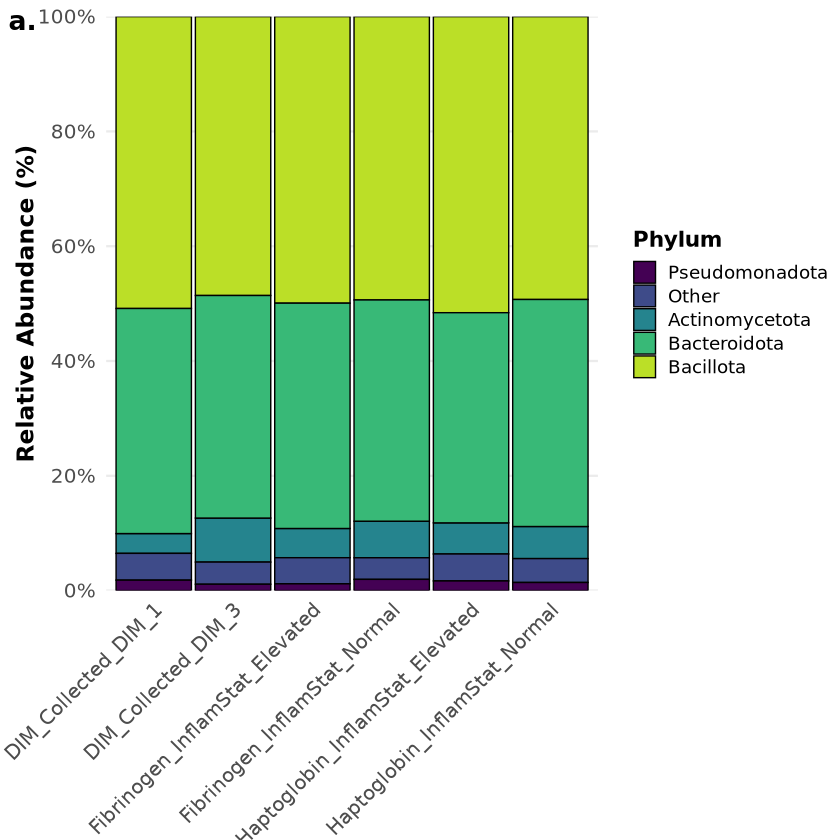

In [95]:
# ----------- Load Required Libraries -----------
library(phyloseq)
library(dplyr)
library(ggplot2)
library(forcats)
library(viridis)
library(tidyr)
library(cowplot)

# ----------- Load Your Normalized Phyloseq Object -----------
ps.norm <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps_normalized_by_CopyNumber.rds")

# ----------- Clean Taxonomy in ps.norm -----------
tax_clean <- tax_table(ps.norm) %>% as.data.frame()
for (i in seq_along(tax_clean)) {
  tax_clean[[i]] <- as.character(tax_clean[[i]])
  tax_clean[[i]][is.na(tax_clean[[i]]) | tax_clean[[i]] == ""] <- paste("Unclassified", colnames(tax_clean)[i])
}
tax_table(ps.norm) <- tax_table(as.matrix(tax_clean))

# ----------- Function to Prepare Phylum-Level Plot Data -----------
prepare_phylum_plot_data <- function(ps_input, group_var) {
  meta <- sample_data(ps_input) %>% as.data.frame()
  meta <- meta[!is.na(meta[[group_var]]), ]

  if (group_var %in% c("DIM", "DIM_Collected")) {
    meta[[group_var]] <- paste0("DIM_", as.character(meta[[group_var]]))
  }

  ps_sub <- prune_samples(rownames(meta), ps_input)
  sample_data(ps_sub)[[group_var]] <- meta[[group_var]]

  ps_tax <- tax_glom(ps_sub, taxrank = "Phylum")
  ps_rel <- transform_sample_counts(ps_tax, function(x) x / sum(x))
  df <- psmelt(ps_rel)

  df$Phylum <- as.character(df$Phylum)
  df$Phylum[is.na(df$Phylum) | df$Phylum == ""] <- "Unclassified_Phylum"

  # Group low-abundance phyla (<1%) into "Other"
  low_abundance_phyla <- df %>%
    group_by(Phylum) %>%
    summarise(MeanRA = mean(Abundance), .groups = "drop") %>%
    filter(MeanRA < 0.01) %>%
    pull(Phylum)

  df$Phylum <- ifelse(df$Phylum %in% low_abundance_phyla, "Other", df$Phylum)

  df <- df %>%
    group_by(Sample) %>%
    mutate(Abundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df$CompositeGroup <- paste0(group_var, "_", df[[group_var]])

  df_summary <- df %>%
    group_by(Sample, CompositeGroup, Phylum) %>%
    summarise(Abundance = sum(Abundance), .groups = "drop") %>%
    group_by(Sample, CompositeGroup) %>%
    mutate(RelAbundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df_summary %>%
    group_by(CompositeGroup, Phylum) %>%
    summarise(RelAbundance = mean(RelAbundance), .groups = "drop") %>%
    group_by(CompositeGroup) %>%
    mutate(RelAbundance = ifelse(row_number() == n(),
                                 pmin(RelAbundance, 1 - sum(RelAbundance[-n()])),
                                 RelAbundance)) %>%
    ungroup()
}

# ----------- Function to Plot Phylum-Level Abundance -----------
plot_phylum_abundance <- function(df, output_prefix = "phylum_abundance", output_dir = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs") {
  df$Phylum <- fct_reorder(df$Phylum, df$RelAbundance, .fun = sum)

  p <- ggplot(df, aes(x = CompositeGroup, y = RelAbundance * 100, fill = Phylum)) +
    geom_col(
      width = 0.95,
      position = position_stack(reverse = TRUE),
      na.rm = TRUE,
      color = "black",
      linewidth = 0.4
    ) +
    scale_y_continuous(
      labels = function(x) paste0(x, "%"),
      limits = c(0, 100),
      breaks = seq(0, 100, by = 20),
      expand = c(0, 0)
    ) +
    scale_fill_viridis_d(option = "D", begin = 0, end = 0.9) +
    labs(
      x = NULL,
      y = "Relative Abundance (%)",
      fill = "Phylum"
    ) +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
      axis.text.y = element_text(size = 12),
      axis.title.y = element_text(size = 14, face = "bold"),
      legend.title = element_text(size = 13, face = "bold"),
      legend.text = element_text(size = 11),
      legend.key.height = unit(0.5, "cm"),
      legend.key.width = unit(0.5, "cm"),
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank(),
      plot.margin = margin(10, 10, 10, 10)
    )

  return(p)  # Only return the plot, don't save it
}

# ----------- Prepare Data and Generate Plot with Label "a." -----------
df_phylum <- bind_rows(
  prepare_phylum_plot_data(ps.norm, "Haptoglobin_InflamStat"),
  prepare_phylum_plot_data(ps.norm, "Fibrinogen_InflamStat"),
  prepare_phylum_plot_data(ps.norm, "DIM_Collected")
)

# Generate base plot
p_base <- plot_phylum_abundance(df_phylum)

# Add "a." label to top-left outside
a. <- ggdraw(p_base) +
  draw_plot_label(label = "a.", x = 0, y = 1, hjust = -0.3, vjust = 1.5, fontface = "bold", size = 16)

# Display the figure
print(a.)


In [99]:
#### Plot where all the samples in each catory with relative abunce will be there

In [14]:
# Calculate mean relative abundance (%) across all samples
top5_phyla_pct <- df_phylum_long %>%
  group_by(Phylum) %>%
  summarise(MeanRelAbundance = mean(Abundance) * 100, .groups = "drop") %>%
  arrange(desc(MeanRelAbundance)) %>%
  slice_head(n = 5)

print(top5_phyla_pct)


# A tibble: 5 × 2
  Phylum         MeanRelAbundance
  <chr>                     <dbl>
1 Bacillota                49.9  
2 Bacteroidota             19.1  
3 Actinomycetota            5.42 
4 Pseudomonadota            2.28 
5 Spirochaetota             0.922


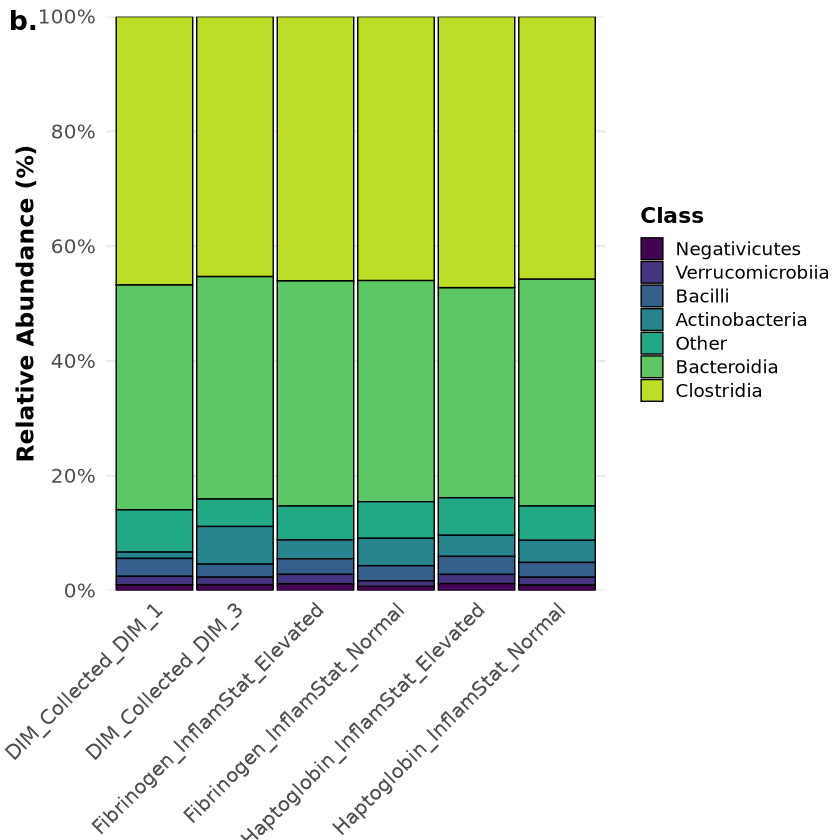

In [100]:
# ----------- Load Required Libraries -----------
library(phyloseq)
library(dplyr)
library(ggplot2)
library(forcats)
library(viridis)
library(cowplot)

# ----------- Load Your Phyloseq Object -----------
ps.norm <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/GP_ps.st.decontam.rds")

# ----------- Clean Taxonomy in ps.norm -----------
tax_clean <- tax_table(ps.norm) %>% as.data.frame()
for (i in seq_along(tax_clean)) {
  tax_clean[[i]] <- as.character(tax_clean[[i]])
  tax_clean[[i]][is.na(tax_clean[[i]]) | tax_clean[[i]] == ""] <- paste("Unclassified", colnames(tax_clean)[i])
}
tax_table(ps.norm) <- tax_table(as.matrix(tax_clean))

# ----------- Relative Abundance Preparation Function (Class) -----------
prepare_class_plot_data <- function(ps_input, group_var) {
  meta <- sample_data(ps_input) %>% as.data.frame()
  meta <- meta[!is.na(meta[[group_var]]), ]

  if (group_var %in% c("DIM", "DIM_Collected")) {
    meta[[group_var]] <- paste0("DIM_", as.character(meta[[group_var]]))
  }

  ps_sub <- prune_samples(rownames(meta), ps_input)
  sample_data(ps_sub)[[group_var]] <- meta[[group_var]]

  ps_tax <- tax_glom(ps_sub, taxrank = "Class")
  ps_rel <- transform_sample_counts(ps_tax, function(x) x / sum(x))
  df <- psmelt(ps_rel)

  df$Class <- as.character(df$Class)
  df$Class[is.na(df$Class) | df$Class == ""] <- "Unclassified_Class"

  # Group low-abundance classes (<1%) into "Other"
  low_abundance_classes <- df %>%
    group_by(Class) %>%
    summarise(MeanRA = mean(Abundance), .groups = "drop") %>%
    filter(MeanRA < 0.01) %>%
    pull(Class)

  df$Class <- ifelse(df$Class %in% low_abundance_classes, "Other", df$Class)

  df <- df %>%
    group_by(Sample) %>%
    mutate(Abundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df$CompositeGroup <- paste0(group_var, "_", df[[group_var]])

  df_summary <- df %>%
    group_by(Sample, CompositeGroup, Class) %>%
    summarise(Abundance = sum(Abundance), .groups = "drop") %>%
    group_by(Sample, CompositeGroup) %>%
    mutate(RelAbundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df_summary %>%
    group_by(CompositeGroup, Class) %>%
    summarise(RelAbundance = mean(RelAbundance), .groups = "drop") %>%
    group_by(CompositeGroup) %>%
    mutate(RelAbundance = ifelse(row_number() == n(),
                                 pmin(RelAbundance, 1 - sum(RelAbundance[-n()])),
                                 RelAbundance)) %>%
    ungroup()
}

# ----------- Plotting Function for Class -----------
plot_class_abundance <- function(df) {
  df$Class <- fct_reorder(df$Class, df$RelAbundance, .fun = sum)

  ggplot(df, aes(x = CompositeGroup, y = RelAbundance * 100, fill = Class)) +
    geom_col(
      width = 0.95,
      position = position_stack(reverse = TRUE),
      na.rm = TRUE,
      color = "black",
      linewidth = 0.4
    ) +
    scale_y_continuous(
      labels = function(x) paste0(x, "%"),
      limits = c(0, 100),
      breaks = seq(0, 100, by = 20),
      expand = c(0, 0)
    ) +
    scale_fill_viridis_d(option = "D", begin = 0, end = 0.9) +
    labs(
      x = NULL,
      y = "Relative Abundance (%)",
      fill = "Class"
    ) +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
      axis.text.y = element_text(size = 12),
      axis.title.y = element_text(size = 14, face = "bold"),
      legend.title = element_text(size = 13, face = "bold"),
      legend.text = element_text(size = 11),
      legend.key.height = unit(0.5, "cm"),
      legend.key.width = unit(0.5, "cm"),
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank(),
      plot.margin = margin(10, 10, 10, 10)
    )
}

# ----------- Prepare and Plot Data -----------
df_class <- bind_rows(
  prepare_class_plot_data(ps.norm, "Haptoglobin_InflamStat"),
  prepare_class_plot_data(ps.norm, "Fibrinogen_InflamStat"),
  prepare_class_plot_data(ps.norm, "DIM_Collected")
)

p_class <- plot_class_abundance(df_class)

# ----------- Add "b." to Top-Left Outside the Plot -----------
b. <- ggdraw(p_class) +
  draw_plot_label(label = "b.", x = 0, y = 1, hjust = -0.3, vjust = 1.5, fontface = "bold", size = 16)

# ----------- Display Only (Don't Save) -----------
print(b.)


In [18]:
# ----------- Load Required Packages -----------
library(phyloseq)
library(dplyr)
library(tidyr)
library(writexl)

# ----------- Agglomerate to Class Level -----------
ps_class <- tax_glom(ps.norm, taxrank = "Class")
ps_class_rel <- transform_sample_counts(ps_class, function(x) x / sum(x))

# ----------- Melt and Clean -----------
df_class_long <- psmelt(ps_class_rel)
df_class_long$Class <- as.character(df_class_long$Class)
df_class_long$Class[is.na(df_class_long$Class) | df_class_long$Class == ""] <- "Unclassified_Class"

# ----------- Summarize and Pivot Wider -----------
df_class_wide <- df_class_long %>%
  group_by(Sample, Class) %>%
  summarise(RelAbundance = sum(Abundance), .groups = "drop") %>%
  pivot_wider(names_from = Class, values_from = RelAbundance, values_fill = 0)

# ----------- Save as Excel File -----------
write_xlsx(df_class_wide, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Class_Relative_Abundance_Per_Sample.xlsx")


In [15]:
# Agglomerate to Class level
ps_class <- tax_glom(ps.norm, taxrank = "Class")

# Convert to relative abundance
ps_class_rel <- transform_sample_counts(ps_class, function(x) x / sum(x))

# Long format
df_class_long <- psmelt(ps_class_rel)
df_class_long$Class <- as.character(df_class_long$Class)
df_class_long$Class[is.na(df_class_long$Class) | df_class_long$Class == ""] <- "Unclassified_Class"

# Summarize and extract top 20 by mean relative abundance
top20_classes_pct <- df_class_long %>%
  group_by(Class) %>%
  summarise(MeanRelAbundance = mean(Abundance) * 100, .groups = "drop") %>%
  arrange(desc(MeanRelAbundance)) %>%
  slice_head(n = 20)

# View result
top20_classes_pct


Class,MeanRelAbundance
<chr>,<dbl>
Clostridia,22.916703670
Bacteroidia,19.077254306
Actinobacteria,3.755743969
Bacilli,1.529552800
Verrucomicrobiia,1.354999646
Gammaproteobacteria,1.119617502
Negativicutes,1.051652187
Spirochaetia,0.922306283
Coriobacteriia,0.833465894


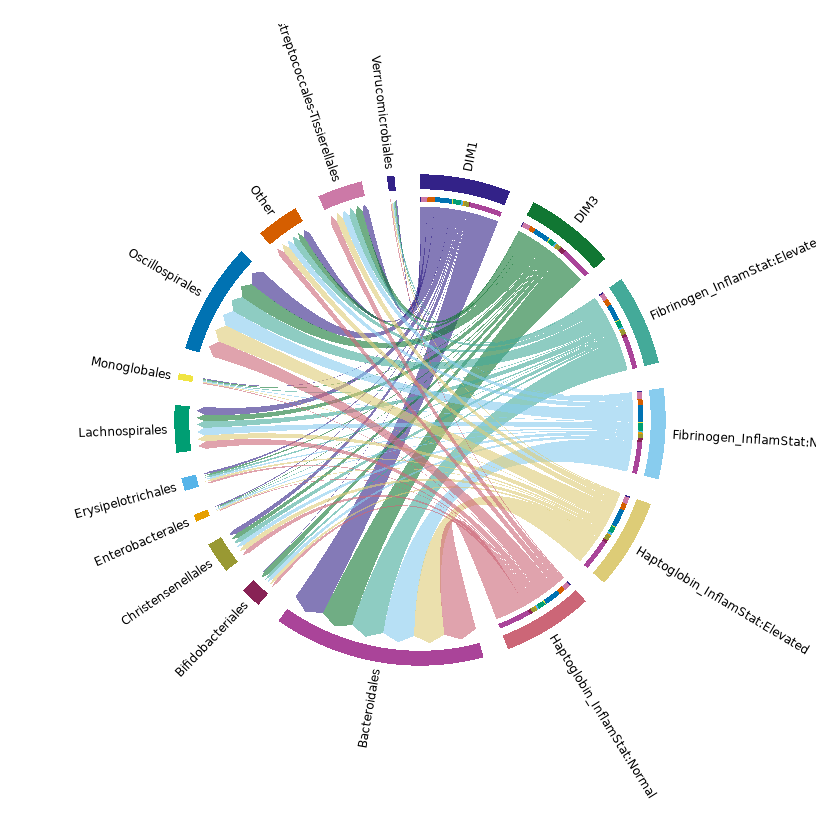

In [109]:
# Order level relative abundance
# ----------- Prepare Data Function (All Orders ≥1% RA) -----------
prepare_order_chord_data <- function(ps_input, group_var, abundance_threshold = 0.01) {
  meta <- sample_data(ps_input) %>% as.data.frame()

  # Define DIM1 and DIM3 from sample names
  if (group_var == "DIM_Collected") {
    sample_names <- rownames(meta)
    meta[[group_var]] <- ifelse(grepl("D1LM", sample_names), "DIM1",
                                ifelse(grepl("D3LM", sample_names), "DIM3", NA))
  }

  meta <- meta[!is.na(meta[[group_var]]), ]
  ps_sub <- prune_samples(rownames(meta), ps_input)
  sample_data(ps_sub)[[group_var]] <- meta[[group_var]]

  ps_tax <- tax_glom(ps_sub, taxrank = "Order")
  df <- psmelt(ps_tax)

  df$Order <- as.character(df$Order)
  df$Order[is.na(df$Order) | df$Order == ""] <- "Unclassified_Order"

  if (group_var %in% c("Haptoglobin_InflamStat", "Fibrinogen_InflamStat")) {
    df$Group <- paste0(group_var, ":", as.character(df[[group_var]]))
  } else {
    df$Group <- as.character(df[[group_var]])
  }

  # Normalize within sample
  df <- df %>%
    group_by(Sample) %>%
    mutate(RelAbund = Abundance / sum(Abundance)) %>%
    ungroup()

  # Get orders with mean RA ≥ threshold
  abundant_orders <- df %>%
    group_by(Order) %>%
    summarise(MeanRA = mean(RelAbund), .groups = "drop") %>%
    filter(MeanRA >= abundance_threshold) %>%
    pull(Order)

  # Group low-abundance orders as "Other"
  df$Order <- ifelse(df$Order %in% abundant_orders, df$Order, "Other")

  df %>%
    group_by(Group, Order) %>%
    summarise(RelAbund = sum(Abundance), .groups = "drop") %>%
    group_by(Group) %>%
    mutate(RelAbund = RelAbund / sum(RelAbund)) %>%
    ungroup()
}
# ----------- Shorten Group Names for Readability -----------
shorten_group_names <- function(name) {
  name <- gsub("Haptoglobin_InflamStat_Normal", "Hapt_Normal", name)
  name <- gsub("Haptoglobin_InflamStat_Elevated", "Hapt_Elevated", name)
  name <- gsub("Fibrinogen_InflamStat_Normal", "Fib_Normal", name)
  name <- gsub("Fibrinogen_InflamStat_Elevated", "Fib_Elevated", name)
  name <- gsub("DIM1", "DIM1", name)
  name <- gsub("DIM3", "DIM3", name)
  return(name)
}

df_chord$Group <- shorten_group_names(df_chord$Group)
# ----------- Combine Chord Data -----------
df_chord <- bind_rows(
  prepare_order_chord_data(ps.norm, "Haptoglobin_InflamStat", abundance_threshold = 0.01),
  prepare_order_chord_data(ps.norm, "Fibrinogen_InflamStat", abundance_threshold = 0.01),
  prepare_order_chord_data(ps.norm, "DIM_Collected", abundance_threshold = 0.01)
)

# ----------- Build Matrix for Chord Plot -----------
chord_mat <- df_chord %>%
  group_by(Group, Order) %>%
  summarise(Weight = sum(RelAbund), .groups = "drop") %>%
  pivot_wider(names_from = Order, values_from = Weight, values_fill = 0) %>%
  column_to_rownames("Group") %>%
  as.matrix()

# ----------- Assign Nature-Style Publication Colors -----------
all_sectors <- union(rownames(chord_mat), colnames(chord_mat))
n_colors <- length(all_sectors)

nature_palette <- c(
  "#332288", "#117733", "#44AA99", "#88CCEE",
  "#DDCC77", "#CC6677", "#AA4499", "#882255",
  "#999933", "#E69F00", "#56B4E9", "#009E73",
  "#F0E442", "#0072B2", "#D55E00", "#CC79A7"
)

color_vector <- rep(nature_palette, length.out = n_colors)
names(color_vector) <- all_sectors

# ----------- Plot Chord Diagram -----------
circos.clear()
circos.par(start.degree = 90, gap.degree = 6)
chordDiagram(
  chord_mat,
  transparency = 0.4,
  annotationTrack = "grid",
  preAllocateTracks = list(track.height = 0.3),
  grid.col = color_vector,
  directional = 1,
  direction.type = c("arrows", "diffHeight"),
  link.arr.type = "big.arrow"
)

# ----------- Add Sector Labels -----------
circos.trackPlotRegion(track.index = 1, panel.fun = function(x, y) {
  sector_name <- get.cell.meta.data("sector.index")
  circos.text(CELL_META$xcenter, CELL_META$ylim[1], sector_name,
              facing = "clockwise", niceFacing = TRUE,
              adj = c(0, 0.5), cex = 0.6)
}, bg.border = NA)



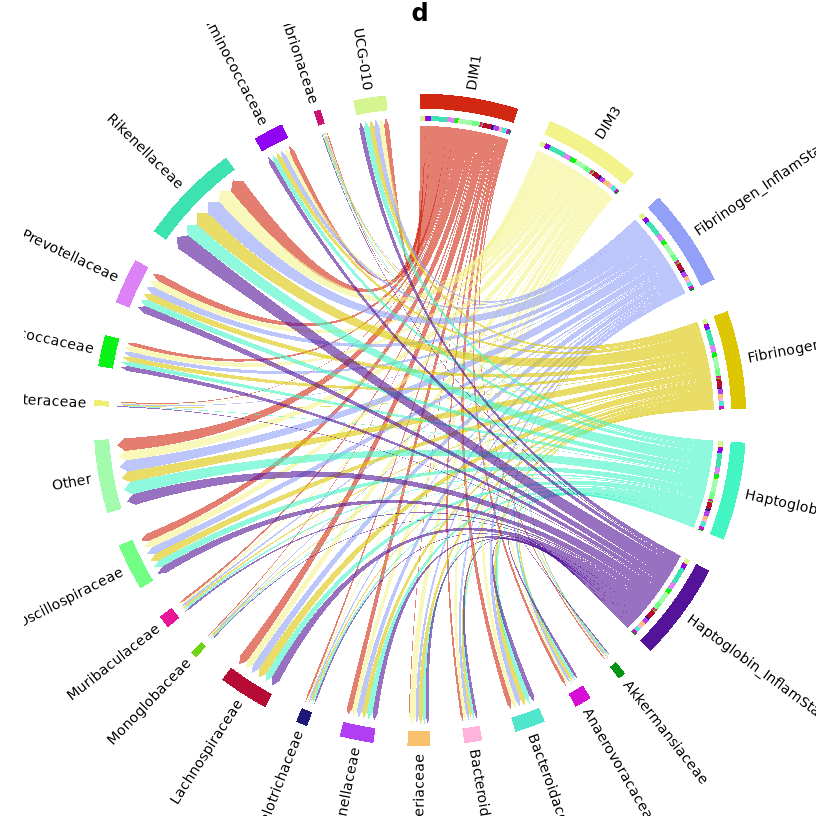

In [68]:
#At Family level
# ----------- Prepare Data Function with 1% Threshold -----------
prepare_family_chord_data <- function(ps_input, group_var, abundance_threshold = 0.01) {
  meta <- sample_data(ps_input) %>% as.data.frame()

  # Define DIM1 and DIM3 using sample names
  if (group_var == "DIM_Collected") {
    sample_names <- rownames(meta)
    meta[[group_var]] <- ifelse(grepl("D1LM", sample_names), "DIM1",
                                ifelse(grepl("D3LM", sample_names), "DIM3", NA))
  }

  # Remove NAs
  meta <- meta[!is.na(meta[[group_var]]), ]
  ps_sub <- prune_samples(rownames(meta), ps_input)
  sample_data(ps_sub)[[group_var]] <- meta[[group_var]]

  # Aggregate at Family level
  ps_tax <- tax_glom(ps_sub, taxrank = "Family")
  df <- psmelt(ps_tax)

  df$Family <- as.character(df$Family)
  df$Family[is.na(df$Family) | df$Family == ""] <- "Unclassified_Family"

  # Label group
  if (group_var %in% c("Haptoglobin_InflamStat", "Fibrinogen_InflamStat")) {
    df$Group <- paste0(group_var, ":", as.character(df[[group_var]]))
  } else if (group_var == "DIM_Collected") {
    df$Group <- as.character(df[[group_var]])
  }

  # Normalize within each sample
  df <- df %>%
    group_by(Sample) %>%
    mutate(RelAbund = Abundance / sum(Abundance)) %>%
    ungroup()

  # Compute mean abundance across all samples
  abundant_families <- df %>%
    group_by(Family) %>%
    summarise(MeanRA = mean(RelAbund), .groups = "drop") %>%
    filter(MeanRA >= abundance_threshold) %>%
    pull(Family)

  df$Family <- ifelse(df$Family %in% abundant_families, df$Family, "Other")

  # Summarize by group
  df %>%
    group_by(Group, Family) %>%
    summarise(RelAbund = sum(Abundance), .groups = "drop") %>%
    group_by(Group) %>%
    mutate(RelAbund = RelAbund / sum(RelAbund)) %>%
    ungroup()
}

# ----------- Combine Chord Data -----------
df_chord_family <- bind_rows(
  prepare_family_chord_data(ps.norm, "Haptoglobin_InflamStat", abundance_threshold = 0.01),
  prepare_family_chord_data(ps.norm, "Fibrinogen_InflamStat", abundance_threshold = 0.01),
  prepare_family_chord_data(ps.norm, "DIM_Collected", abundance_threshold = 0.01)
)

# ----------- Build Matrix for Chord Plot -----------
chord_mat_family <- df_chord_family %>%
  group_by(Group, Family) %>%
  summarise(Weight = sum(RelAbund), .groups = "drop") %>%
  pivot_wider(names_from = Family, values_from = Weight, values_fill = 0) %>%
  column_to_rownames("Group") %>%
  as.matrix()

# ----------- Plot Chord Diagram with Labels -----------
circos.clear()
circos.par(start.degree = 90, gap.degree = 6)
chordDiagram(
  chord_mat_family,
  transparency = 0.4,
  annotationTrack = "grid",
  preAllocateTracks = list(track.height = 0.08),
  directional = 1,
  direction.type = c("arrows", "diffHeight"),
  link.arr.type = "big.arrow"
)

# Add sector labels
circos.trackPlotRegion(track.index = 1, panel.fun = function(x, y) {
  sector_name <- get.cell.meta.data("sector.index")
  circos.text(CELL_META$xcenter, CELL_META$ylim[1], sector_name,
              facing = "clockwise", niceFacing = TRUE, adj = c(0, 0.5),
              cex = 0.7)
}, bg.border = NA)

title("d")


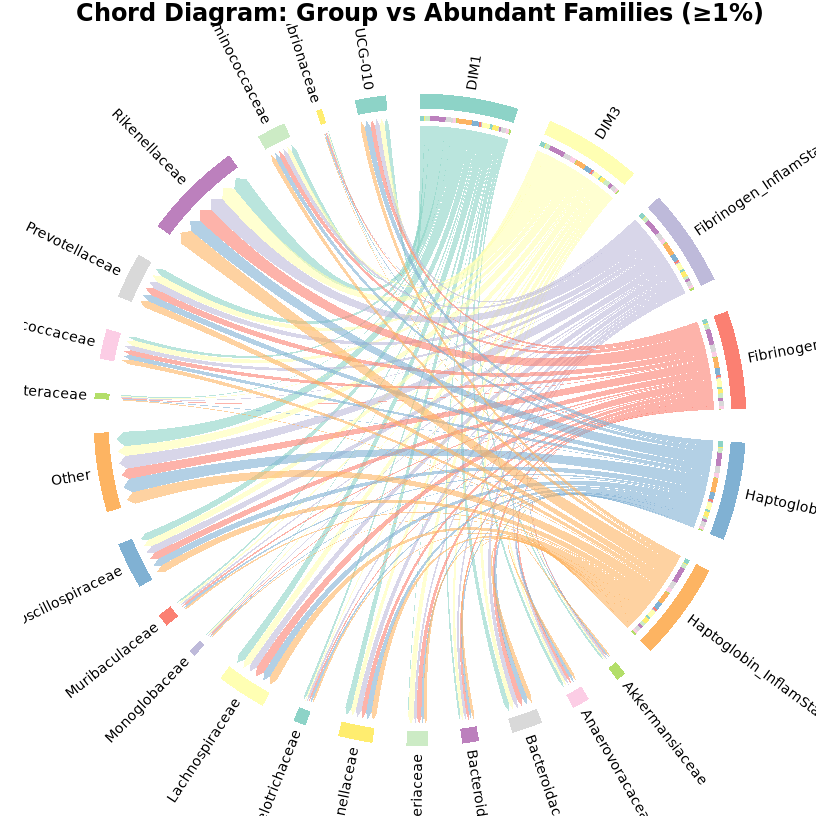

In [31]:
# ----------- Load Required Libraries -----------
library(phyloseq)
library(dplyr)
library(tidyr)
library(tibble)
library(circlize)
library(RColorBrewer)

# ----------- Prepare Data Function (With 1% Filter) -----------
prepare_family_chord_data <- function(ps_input, group_var, abundance_threshold = 0.01) {
  meta <- sample_data(ps_input) %>% as.data.frame()

  if (group_var == "DIM_Collected") {
    sample_names <- rownames(meta)
    meta[[group_var]] <- ifelse(grepl("D1LM", sample_names), "DIM1",
                                ifelse(grepl("D3LM", sample_names), "DIM3", NA))
  }

  meta <- meta[!is.na(meta[[group_var]]), ]
  ps_sub <- prune_samples(rownames(meta), ps_input)
  sample_data(ps_sub)[[group_var]] <- meta[[group_var]]

  ps_tax <- tax_glom(ps_sub, taxrank = "Family")
  df <- psmelt(ps_tax)

  df$Family <- as.character(df$Family)
  df$Family[is.na(df$Family) | df$Family == ""] <- "Unclassified_Family"

  if (group_var %in% c("Haptoglobin_InflamStat", "Fibrinogen_InflamStat")) {
    df$Group <- paste0(group_var, ":", as.character(df[[group_var]]))
  } else {
    df$Group <- as.character(df[[group_var]])
  }

  df <- df %>%
    group_by(Sample) %>%
    mutate(RelAbund = Abundance / sum(Abundance)) %>%
    ungroup()

  abundant_families <- df %>%
    group_by(Family) %>%
    summarise(MeanRA = mean(RelAbund), .groups = "drop") %>%
    filter(MeanRA >= abundance_threshold) %>%
    pull(Family)

  df$Family <- ifelse(df$Family %in% abundant_families, df$Family, "Other")

  df %>%
    group_by(Group, Family) %>%
    summarise(RelAbund = sum(Abundance), .groups = "drop") %>%
    group_by(Group) %>%
    mutate(RelAbund = RelAbund / sum(RelAbund)) %>%
    ungroup()
}

# ----------- Combine Chord Data -----------
df_chord_family <- bind_rows(
  prepare_family_chord_data(ps.norm, "Haptoglobin_InflamStat", abundance_threshold = 0.01),
  prepare_family_chord_data(ps.norm, "Fibrinogen_InflamStat", abundance_threshold = 0.01),
  prepare_family_chord_data(ps.norm, "DIM_Collected", abundance_threshold = 0.01)
)

# ----------- Build Matrix -----------
chord_mat_family <- df_chord_family %>%
  group_by(Group, Family) %>%
  summarise(Weight = sum(RelAbund), .groups = "drop") %>%
  pivot_wider(names_from = Family, values_from = Weight, values_fill = 0) %>%
  column_to_rownames("Group") %>%
  as.matrix()

# ----------- Assign Publication-Ready Colors -----------
all_sectors <- union(rownames(chord_mat_family), colnames(chord_mat_family))
n_colors <- length(all_sectors)

# Use ColorBrewer palette (Set3 is good for categories, max 12 colors repeated if needed)
palette_base <- brewer.pal(min(n_colors, 12), "Set3")
color_vector <- rep(palette_base, length.out = n_colors)
names(color_vector) <- all_sectors

# ----------- Plot Chord Diagram -----------
circos.clear()
circos.par(start.degree = 90, gap.degree = 6)
chordDiagram(
  chord_mat_family,
  transparency = 0.4,
  annotationTrack = "grid",
  preAllocateTracks = list(track.height = 0.08),
  grid.col = color_vector,
  directional = 1,
  direction.type = c("arrows", "diffHeight"),
  link.arr.type = "big.arrow"
)

# Add sector labels
circos.trackPlotRegion(track.index = 1, panel.fun = function(x, y) {
  sector_name <- get.cell.meta.data("sector.index")
  circos.text(CELL_META$xcenter, CELL_META$ylim[1], sector_name,
              facing = "clockwise", niceFacing = TRUE, adj = c(0, 0.5),
              cex = 0.7)
}, bg.border = NA)

title("d")


In [ ]:

# ----------- Load Your Normalized Phyloseq Object -----------
ps.norm <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps_normalized_by_CopyNumber.rds")

# ----------- Clean Taxonomy -----------
tax_clean <- tax_table(ps.norm) %>% as.data.frame()
for (i in seq_along(tax_clean)) {
  tax_clean[[i]] <- as.character(tax_clean[[i]])
  tax_clean[[i]][is.na(tax_clean[[i]]) | tax_clean[[i]] == ""] <- paste("Unclassified", colnames(tax_clean)[i])
}
tax_table(ps.norm) <- tax_table(as.matrix(tax_clean))

# ----------- Shared Functions for Bar Plot Panels (Phylum/Class) -----------
prepare_abundance_data <- function(ps_input, group_var, rank_level) {
  meta <- sample_data(ps_input) %>% as.data.frame()
  meta <- meta[!is.na(meta[[group_var]]), ]

  if (group_var == "DIM_Collected") {
    sample_names <- rownames(meta)
    meta[[group_var]] <- ifelse(grepl("D1LM", sample_names), "DIM1",
                                ifelse(grepl("D3LM", sample_names), "DIM3", NA))
  }

  ps_sub <- prune_samples(rownames(meta), ps_input)
  sample_data(ps_sub)[[group_var]] <- meta[[group_var]]

  ps_tax <- tax_glom(ps_sub, taxrank = rank_level)
  ps_rel <- transform_sample_counts(ps_tax, function(x) x / sum(x))
  df <- psmelt(ps_rel)

  df[[rank_level]] <- as.character(df[[rank_level]])
  df[[rank_level]][is.na(df[[rank_level]]) | df[[rank_level]] == ""] <- paste0("Unclassified_", rank_level)

  # Group low-abundance taxa
  low_taxa <- df %>%
    group_by(.data[[rank_level]]) %>%
    summarise(MeanRA = mean(Abundance), .groups = "drop") %>%
    filter(MeanRA < 0.01) %>%
    pull(.data[[rank_level]])

  df[[rank_level]] <- ifelse(df[[rank_level]] %in% low_taxa, "Other", df[[rank_level]])

  df <- df %>%
    group_by(Sample) %>%
    mutate(Abundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df$CompositeGroup <- paste0(group_var, "_", df[[group_var]])

  df %>%
    group_by(Sample, CompositeGroup, .data[[rank_level]]) %>%
    summarise(Abundance = sum(Abundance), .groups = "drop") %>%
    group_by(Sample, CompositeGroup) %>%
    mutate(RelAbundance = Abundance / sum(Abundance)) %>%
    ungroup() %>%
    group_by(CompositeGroup, .data[[rank_level]]) %>%
    summarise(RelAbundance = mean(RelAbundance), .groups = "drop") %>%
    group_by(CompositeGroup) %>%
    mutate(RelAbundance = ifelse(row_number() == n(),
                                 pmin(RelAbundance, 1 - sum(RelAbundance[-n()])),
                                 RelAbundance)) %>%
    ungroup()
}

plot_abundance <- function(df, rank_level, label = "Relative Abundance (%)") {
  df[[rank_level]] <- fct_reorder(df[[rank_level]], df$RelAbundance, .fun = sum)
  ggplot(df, aes(x = CompositeGroup, y = RelAbundance * 100, fill = .data[[rank_level]])) +
    geom_col(position = position_stack(reverse = TRUE), width = 0.95, color = "black", linewidth = 0.4) +
    scale_y_continuous(labels = function(x) paste0(x, "%"), limits = c(0, 100)) +
    scale_fill_viridis_d(option = "D", begin = 0, end = 0.9) +
    labs(x = NULL, y = label, fill = rank_level) +
    theme_minimal(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

# ----------- Prepare Panel A and B (Phylum and Class) -----------
df_phylum <- bind_rows(
  prepare_abundance_data(ps.norm, "Haptoglobin_InflamStat", "Phylum"),
  prepare_abundance_data(ps.norm, "Fibrinogen_InflamStat", "Phylum"),
  prepare_abundance_data(ps.norm, "DIM_Collected", "Phylum")
)
fig_a <- plot_abundance(df_phylum, "Phylum")

df_class <- bind_rows(
  prepare_abundance_data(ps.norm, "Haptoglobin_InflamStat", "Class"),
  prepare_abundance_data(ps.norm, "Fibrinogen_InflamStat", "Class"),
  prepare_abundance_data(ps.norm, "DIM_Collected", "Class")
)
fig_b <- plot_abundance(df_class, "Class")


# ----------- Prepare Panels C and D (Chord Plots) -----------
save_chord <- function(rank, filename, group_var = c("Haptoglobin_InflamStat", "Fibrinogen_InflamStat", "DIM_Collected")) {
  prepare_func <- function(g) {
    meta <- sample_data(ps.norm) %>% as.data.frame()
    if (g == "DIM_Collected") {
      meta[[g]] <- ifelse(grepl("D1LM", rownames(meta)), "DIM1", ifelse(grepl("D3LM", rownames(meta)), "DIM3", NA))
    }
    meta <- meta[!is.na(meta[[g]]), ]
    ps_sub <- prune_samples(rownames(meta), ps.norm)
    sample_data(ps_sub)[[g]] <- meta[[g]]
    ps_tax <- tax_glom(ps_sub, taxrank = rank)
    df <- psmelt(ps_tax)
    df$Group <- paste0(g, ":", df[[g]])
    df[[rank]] <- ifelse(is.na(df[[rank]]) | df[[rank]] == "", paste0("Unclassified_", rank), df[[rank]])
    df <- df %>% group_by(Sample) %>% mutate(RelAbund = Abundance / sum(Abundance)) %>% ungroup()
    keep <- df %>% group_by(.data[[rank]]) %>%
      summarise(MeanRA = mean(RelAbund), .groups = "drop") %>%
      filter(MeanRA >= 0.01) %>% pull(.data[[rank]])
    df[[rank]] <- ifelse(df[[rank]] %in% keep, df[[rank]], "Other")
    df %>%
      group_by(Group, .data[[rank]]) %>%
      summarise(RelAbund = sum(Abundance), .groups = "drop") %>%
      group_by(Group) %>%
      mutate(RelAbund = RelAbund / sum(RelAbund)) %>%
      ungroup()
  }

  df_chord <- bind_rows(lapply(group_var, prepare_func))
  chord_mat <- df_chord %>%
    group_by(Group, .data[[rank]]) %>%
    summarise(Weight = sum(RelAbund), .groups = "drop") %>%
    pivot_wider(names_from = .data[[rank]], values_from = Weight, values_fill = 0) %>%
    column_to_rownames("Group") %>% as.matrix()

  all_sectors <- union(rownames(chord_mat), colnames(chord_mat))
  colors <- rep(brewer.pal(12, "Set3"), length.out = length(all_sectors))
  names(colors) <- all_sectors

  tiff(filename, width = 1800, height = 1800, res = 300)
  circos.clear()
  circos.par(start.degree = 90, gap.degree = 6)
  chordDiagram(
    chord_mat,
    grid.col = colors,
    transparency = 0.4,
    annotationTrack = "grid",
    preAllocateTracks = list(track.height = 0.08),
    directional = 1,
    direction.type = c("arrows", "diffHeight"),
    link.arr.type = "big.arrow"
  )
  circos.trackPlotRegion(track.index = 1, panel.fun = function(x, y) {
    circos.text(CELL_META$xcenter, CELL_META$ylim[1], CELL_META$sector.index,
                facing = "clockwise", niceFacing = TRUE, adj = c(0, 0.5), cex = 0.6)
  }, bg.border = NA)
  dev.off()
}

# Save c and d chord diagrams
save_chord("Order", "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/fig_c_order_chord.tiff")
save_chord("Family", "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/fig_d_family_chord.tiff")

# Save bar plots a and b
ggsave("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/fig_a_phylum.tiff", fig_a, width = 10, height = 6, dpi = 300)
ggsave("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/fig_b_class.tiff", fig_b, width = 10, height = 6, dpi = 300)


In [75]:
plot_abundance <- function(df, rank_level, label = "Relative Abundance (%)", tag = NULL) {
  df[[rank_level]] <- fct_reorder(df[[rank_level]], df$RelAbundance, .fun = sum)
  ggplot(df, aes(x = CompositeGroup, y = RelAbundance * 100, fill = .data[[rank_level]])) +
    geom_col(position = position_stack(reverse = TRUE), width = 0.95, color = "black", linewidth = 0.4) +
    scale_y_continuous(labels = function(x) paste0(x, "%"), limits = c(0, 100)) +
    scale_fill_viridis_d(option = "D", begin = 0, end = 0.9) +
    labs(x = NULL, y = label, fill = rank_level, tag = tag) +
    theme_minimal(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
          plot.tag = element_text(face = "bold", size = 18, hjust = 0, vjust = 1),
          plot.tag.position = c(0.01, 0.99))
}


In [76]:
fig_a <- plot_abundance(df_phylum, "Phylum", tag = "A")
fig_b <- plot_abundance(df_class, "Class", tag = "B")


In [78]:
df$Group <- gsub("Haptoglobin_InflamStat:Normal", "Hp:Norm", df$Group)
df$Group <- gsub("Haptoglobin_InflamStat:Elevated", "Hp:Elev", df$Group)
df$Group <- gsub("Fibrinogen_InflamStat:Normal", "Fib:Norm", df$Group)
df$Group <- gsub("Fibrinogen_InflamStat:Elevated", "Fib:Elev", df$Group)
df$Group <- gsub("DIM_Collected:D1LM", "DIM1", df$Group)
df$Group <- gsub("DIM_Collected:D3LM", "DIM3", df$Group)
tiff(filename, width = 2400, height = 2400, res = 300)  # Increased dimension


ERROR: Error in df$Group: object of type 'closure' is not subsettable


In [79]:
library(cowplot)

final_figure <- plot_grid(fig_a, fig_b, labels = NULL, ncol = 1, rel_heights = c(1, 1))
ggsave("final_abundance_plot_ab.tiff", final_figure, width = 10, height = 12, dpi = 300)


In [71]:
# ----------- Generate and Save Figure A (Phylum) -----------
df_phylum <- bind_rows(
  prepare_abundance_data(ps.norm, "Haptoglobin_InflamStat", "Phylum"),
  prepare_abundance_data(ps.norm, "Fibrinogen_InflamStat", "Phylum"),
  prepare_abundance_data(ps.norm, "DIM_Collected", "Phylum")
)
fig_a <- plot_abundance(df_phylum, "Phylum")

ggsave(
  filename = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/fig_a_phylum.tiff",
  plot = fig_a,
  width = 10,
  height = 6,
  dpi = 300
)
message("Figure A (Phylum) saved.")

# ----------- Generate and Save Figure B (Class) -----------
df_class <- bind_rows(
  prepare_abundance_data(ps.norm, "Haptoglobin_InflamStat", "Class"),
  prepare_abundance_data(ps.norm, "Fibrinogen_InflamStat", "Class"),
  prepare_abundance_data(ps.norm, "DIM_Collected", "Class")
)
fig_b <- plot_abundance(df_class, "Class")

ggsave(
  filename = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/fig_b_class.tiff",
  plot = fig_b,
  width = 10,
  height = 6,
  dpi = 300
)
message("Figure B (Class) saved.")

# ----------- Save Excel Summary for Class -----------
write.xlsx(
  df_class,
  file = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/class_level_relative_abundance.xlsx",
  asTable = TRUE,
  overwrite = TRUE
)
message("Class-level relative abundance table saved.")


Installing package into ‘/home/ldas/R/x86_64-conda-linux-gnu-library/4.4’
(as ‘lib’ is unspecified)

Warning message in install.packages("magick"):
“installation of package ‘magick’ had non-zero exit status”


In [73]:
library(magick)
library(grid)
library(gridExtra)

# ----------- Load the 4 Panel Images -----------
img_a <- image_read("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/fig_a_phylum.tiff")
img_b <- image_read("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/fig_b_class.tiff")
img_c <- image_read("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/fig_c_order_chord.tiff")
img_d <- image_read("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/fig_d_family_chord.tiff")

# ----------- Resize to same width -----------
target_width <- min(image_info(img_a)$width, image_info(img_b)$width, image_info(img_c)$width, image_info(img_d)$width)
img_a <- image_scale(img_a, paste0(target_width))
img_b <- image_scale(img_b, paste0(target_width))
img_c <- image_scale(img_c, paste0(target_width))
img_d <- image_scale(img_d, paste0(target_width))

# ----------- Add Labels -----------
img_a <- image_annotate(img_a, "a", size = 50, gravity = "northwest", weight = 700, location = "+10+10")
img_b <- image_annotate(img_b, "b", size = 50, gravity = "northwest", weight = 700, location = "+10+10")
img_c <- image_annotate(img_c, "c", size = 50, gravity = "northwest", weight = 700, location = "+10+10")
img_d <- image_annotate(img_d, "d", size = 50, gravity = "northwest", weight = 700, location = "+10+10")

# ----------- Stack into 2x2 Grid -----------
row1 <- image_append(c(img_a, img_b))
row2 <- image_append(c(img_c, img_d))
final_figure <- image_append(c(row1, row2), stack = TRUE)

# ----------- Save Final Composite -----------
output_path <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/FINAL_FIGURE_abcd.tiff"
image_write(final_figure, path = output_path, format = "tiff")

cat("Composite figure saved to:", output_path, "\n")


ERROR: Error in library(magick): there is no package called ‘magick’
